**Imports, Drive mount, and paths**

In [ ]:
import os
import json
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import mixed_precision

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

sns.set(style="whitegrid", context="notebook")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ROOT_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"

# Dataset root folders
EUROSAT_DIR = os.path.join(ROOT_DIR, "eurosat")
UCM_DIR = os.path.join(ROOT_DIR, "uc_merced")

# Subfolders that already exist from Day 1
EUROSAT_MODELS_DIR = os.path.join(EUROSAT_DIR, "models")
EUROSAT_METRICS_DIR = os.path.join(EUROSAT_DIR, "metrics")

UCM_MODELS_DIR = os.path.join(UCM_DIR, "models")
UCM_METRICS_DIR = os.path.join(UCM_DIR, "metrics")

# New folder for all cross‑dataset zero‑shot outputs
CROSS_DIR = os.path.join(ROOT_DIR, "cross_dataset_zero_shot")
os.makedirs(CROSS_DIR, exist_ok=True)

CROSS_METRICS_DIR = os.path.join(CROSS_DIR, "metrics")
CROSS_NPY_DIR = os.path.join(CROSS_DIR, "npy")
CROSS_FIGS_DIR = os.path.join(CROSS_DIR, "figs")

for d in [CROSS_METRICS_DIR, CROSS_NPY_DIR, CROSS_FIGS_DIR]:
    os.makedirs(d, exist_ok=True)

mixed_precision.set_global_policy("mixed_float16")

In [ ]:
import os

print("EUROSAT_DIR:", EUROSAT_DIR)
print("Contents of EUROSAT_DIR:", os.listdir(EUROSAT_DIR))
print("Contents of EUROSAT models dir:", os.listdir(os.path.join(EUROSAT_DIR, "models")))

print("\nUCM_DIR:", UCM_DIR)
print("Contents of UCM_DIR:", os.listdir(UCM_DIR))
print("Contents of UCM models dir:", os.listdir(os.path.join(UCM_DIR, "models")))

EUROSAT_DIR: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat
Contents of EUROSAT_DIR: ['models', 'logs', 'figs', 'metrics', '01_eurosat_resnet50.ipynb', '02_eurosat_densenet121.ipynb', '03_eurosat_mobilenetv2.ipynb', '04_eurosat_efficientnetb0.ipynb']
Contents of EUROSAT models dir: ['eurosat_resnet50_best.weights.h5', 'eurosat_resnet50_full.keras', 'eurosat_densenet121_best.weights.h5', 'eurosat_densenet121_full.keras', 'eurosat_mobilenetv2_best.weights.h5', 'eurosat_mobilenetv2_full.keras', 'eurosat_efficientnetb0_best.weights.h5', 'eurosat_efficientnetb0_full.keras']

UCM_DIR: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced
Contents of UCM_DIR: ['models', 'logs', 'figs', 'metrics', '11_ucm_resnet50.ipynb', '12_ucm_densenet121.ipynb', '13_ucm_mobilenetv2.ipynb', '14_ucm_efficientnetb0.ipynb']
Contents of UCM models dir: ['ucm_resnet50_full.keras', 'ucm_resnet50_best.weights.h5', 'ucm_densenet121_best.weights.h5', 'ucm_densenet121_full.keras', '

In [ ]:
print("Raw eurosat_class_mapping:", eurosat_class_mapping)
print("Type of keys:", {type(k) for k in eurosat_class_mapping.keys()})
print("Example item:", next(iter(eurosat_class_mapping.items())))

Raw eurosat_class_mapping: {'class_names': ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']}
Type of keys: {<class 'str'>}
Example item: ('class_names', ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'])


**Load class mappings and set image size**

In [ ]:
# ==== CLASS NAMES FROM JSON ====

# EuroSAT
with open(os.path.join(EUROSAT_METRICS_DIR, "eurosat_class_mapping.json"), "r") as f:
    eurosat_class_mapping = json.load(f)

# UC Merced
with open(os.path.join(UCM_METRICS_DIR, "ucm_class_mapping.json"), "r") as f:
    ucm_class_mapping = json.load(f)

# Both JSONs look like: {"class_names": ["AnnualCrop", "Forest", ...]}
eurosat_class_names = eurosat_class_mapping["class_names"]
ucm_class_names = ucm_class_mapping["class_names"]

eurosat_num_classes = len(eurosat_class_names)
ucm_num_classes = len(ucm_class_names)

print("EuroSAT classes:", eurosat_num_classes, eurosat_class_names)
print("UC Merced classes:", ucm_num_classes, ucm_class_names)

# ==== SHARED DATA SETTINGS (MATCH TRAINING) ====
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

EuroSAT classes: 10 ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
UC Merced classes: 21 ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


**Dataset preparation cell**

In [ ]:
# ==== TFDS LOADERS AND PREPROCESSING (MATCH TRAINING) ====

def load_eurosat_splits():
    builder = tfds.builder("eurosat/rgb")
    builder.download_and_prepare()
    ds_train = builder.as_dataset(split="train[:60%]", as_supervised=True)
    ds_val   = builder.as_dataset(split="train[60%:80%]", as_supervised=True)
    ds_test  = builder.as_dataset(split="train[80%:]", as_supervised=True)
    return ds_train, ds_val, ds_test

def load_ucm_splits():
    builder = tfds.builder("uc_merced")
    builder.download_and_prepare()
    ds_train = builder.as_dataset(split="train[:60%]", as_supervised=True)
    ds_val   = builder.as_dataset(split="train[60%:80%]", as_supervised=True)
    ds_test  = builder.as_dataset(split="train[80%:]", as_supervised=True)
    return ds_train, ds_val, ds_test

def preprocess_image(image, label):
    # Resize to 128x128 and scale to [0,1], identical to training
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare_ds(ds, shuffle=False):
    if shuffle:
        ds = ds.shuffle(10_000, reshuffle_each_iteration=False)
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

eurosat_train_ds, eurosat_val_ds, eurosat_test_raw = load_eurosat_splits()
ucm_train_ds, ucm_val_ds, ucm_test_raw = load_ucm_splits()

# For zero‑shot we only need deterministic test sets (no shuffle)
eurosat_test_ds = prepare_ds(eurosat_test_raw, shuffle=False)
ucm_test_ds = prepare_ds(ucm_test_raw, shuffle=False)

print("EuroSAT test batches:", len(list(eurosat_test_ds)))
print("UC Merced test batches:", len(list(ucm_test_ds)))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/uc_merced/incomplete.KRK3UB_2.0.0/uc_merced-train.tfrecord*...:   0%|     …

Dataset uc_merced downloaded and prepared to /root/tensorflow_datasets/uc_merced/2.0.0. Subsequent calls will reuse this data.
EuroSAT test batches: 85
UC Merced test batches: 7


**Evaluation helper cell**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

def evaluate_model_on_dataset(
    model,
    test_ds,
    class_names,
    save_prefix,
    cross_metrics_dir=CROSS_METRICS_DIR,
    cross_npy_dir=CROSS_NPY_DIR,
    cross_figs_dir=CROSS_FIGS_DIR,
):
    num_classes = len(class_names)

    y_true = []
    y_pred = []

    for batch_images, batch_labels in test_ds:
        logits = model(batch_images, training=False)
        preds = tf.argmax(logits, axis=-1)
        y_true.extend(batch_labels.numpy().tolist())
        y_pred.extend(preds.numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = float((y_true == y_pred).mean().item())
    macro_f1 = float(f1_score(y_true, y_pred, average="macro"))

    # Use explicit label list of correct length
    label_ids = list(range(num_classes))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=label_ids,
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=label_ids,            # ensure same number as target_names
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    metrics = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "classification_report": report_dict,
        "num_samples": int(len(y_true)),
        "num_classes": int(num_classes),
    }

    metrics_path = os.path.join(cross_metrics_dir, f"{save_prefix}_metrics.json")
    y_true_path = os.path.join(cross_npy_dir, f"{save_prefix}_y_true.npy")
    y_pred_path = os.path.join(cross_npy_dir, f"{save_prefix}_y_pred.npy")
    cm_path = os.path.join(cross_npy_dir, f"{save_prefix}_cm.npy")

    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    np.save(y_true_path, y_true)
    np.save(y_pred_path, y_pred)
    np.save(cm_path, cm)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=False,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=class_names,
        yticklabels=class_names,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(save_prefix.replace("_", " "))
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    fig_path = os.path.join(cross_figs_dir, f"{save_prefix}_confusion_matrix.png")
    plt.savefig(fig_path, dpi=300)
    plt.close(fig)

    print(f"Saved metrics to {metrics_path}")
    print(f"Saved y_true to {y_true_path}")
    print(f"Saved y_pred to {y_pred_path}")
    print(f"Saved confusion matrix to {cm_path}")
    print(f"Saved confusion matrix figure to {fig_path}")

    return metrics


**EuroSAT → UC Merced evaluation cell**

In [ ]:
# Use the actual .keras filenames
eurosat_model_files = [
    "eurosat_resnet50_full.keras",
    "eurosat_densenet121_full.keras",
    "eurosat_mobilenetv2_full.keras",
    "eurosat_efficientnetb0_full.keras",
]

zero_shot_results_eurosat_to_ucm = []

for model_file in eurosat_model_files:
    model_path = os.path.join(EUROSAT_MODELS_DIR, model_file)
    print("\n======================================")
    print("Evaluating EuroSAT model on UC Merced:", model_path)

    # Keras 3 can load its own .keras format directly
    model = tf.keras.models.load_model(model_path, compile=False)

    base_name = model_file.replace(".keras", "")
    prefix = f"cross_eurosat_to_ucm_{base_name}"

    metrics = evaluate_model_on_dataset(
        model=model,
        test_ds=ucm_test_ds,
        class_names=ucm_class_names,
        save_prefix=prefix,
    )

    zero_shot_results_eurosat_to_ucm.append(
        {
            "train_dataset": "EuroSAT",
            "test_dataset": "UC Merced",
            "model": base_name.replace("eurosat_", ""),
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
        }
    )

summary_path_e2u = os.path.join(
    CROSS_METRICS_DIR, "zero_shot_eurosat_to_ucm_summary.json"
)
with open(summary_path_e2u, "w") as f:
    json.dump(zero_shot_results_eurosat_to_ucm, f, indent=2)

print("\nSaved EuroSAT → UC Merced zero‑shot summary to:", summary_path_e2u)


Evaluating EuroSAT model on UC Merced: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_resnet50_full.keras
Saved metrics to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/metrics/cross_eurosat_to_ucm_eurosat_resnet50_full_metrics.json
Saved y_true to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/npy/cross_eurosat_to_ucm_eurosat_resnet50_full_y_true.npy
Saved y_pred to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/npy/cross_eurosat_to_ucm_eurosat_resnet50_full_y_pred.npy
Saved confusion matrix to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/npy/cross_eurosat_to_ucm_eurosat_resnet50_full_cm.npy
Saved confusion matrix figure to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/figs/cross_eurosat_to_ucm_eurosat_resnet50_full_confusion_matrix.png

Evaluating EuroSAT model on UC 

**EuroSAT → UC Merced confusion matrix**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

def plot_confusion_matrix_from_npy(
    cm_path,
    class_names,
    title,
    normalize=False,
    figsize=(14, 12),
    annot_fontsize=9,
    label_fontsize=11,
    tick_fontsize=9,
):
    cm = np.load(cm_path)

    if normalize:
        cm_sum = cm.sum(axis=1, keepdims=True)
        cm_sum[cm_sum == 0] = 1
        cm_norm = cm / cm_sum
        data = cm_norm
        fmt = ".2f"
        vmin, vmax = 0.0, 1.0
    else:
        data = cm
        fmt = "d"
        vmin, vmax = None, None

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        data,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        vmin=vmin,
        vmax=vmax,
        square=True,
        linewidths=0.5,
        linecolor="gray",
        annot_kws={"size": annot_fontsize},
    )
    ax.set_xlabel("Predicted", fontsize=label_fontsize)
    ax.set_ylabel("True", fontsize=label_fontsize)
    ax.set_title(title, fontsize=label_fontsize + 2)
    plt.xticks(rotation=45, ha="right", fontsize=tick_fontsize)
    plt.yticks(rotation=0, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.show()

**For EuroSAT ResNet50 → UC Merced (zero‑shot)**

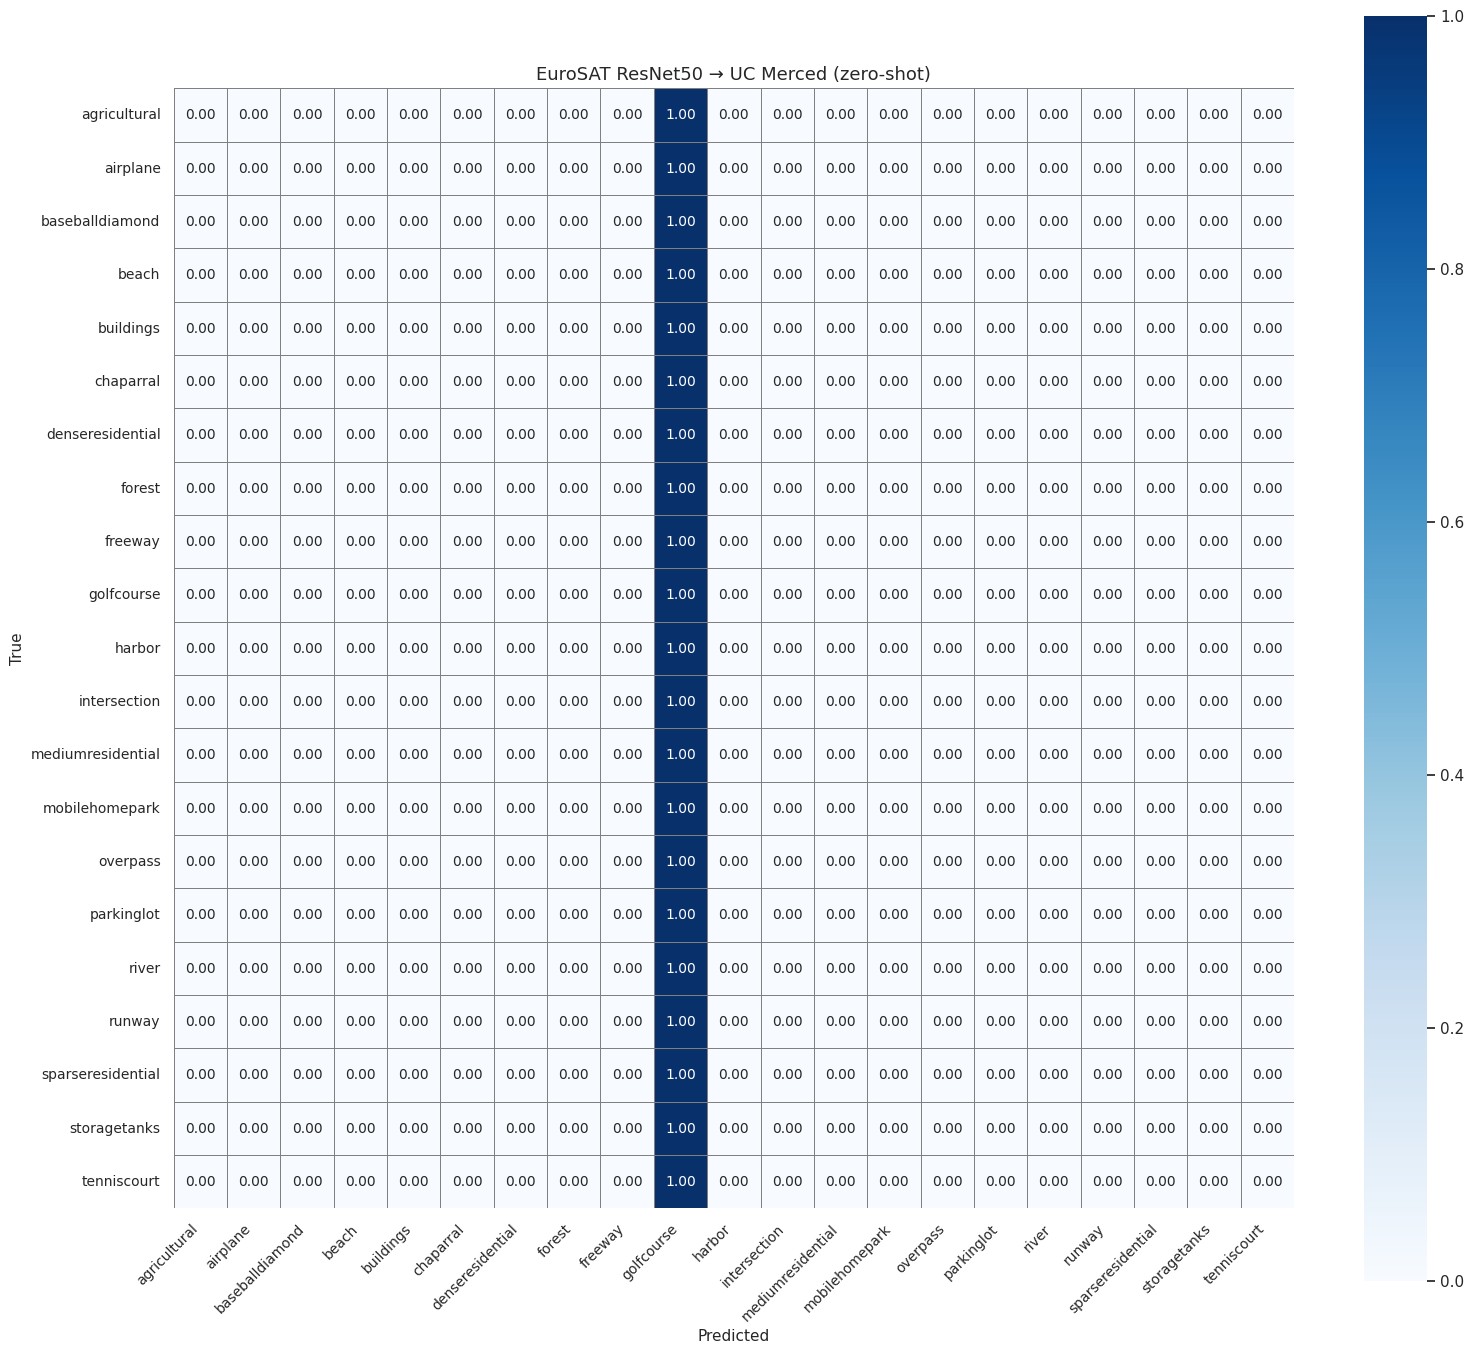

In [ ]:
cm_path = os.path.join(
    CROSS_NPY_DIR,
    "cross_eurosat_to_ucm_eurosat_resnet50_full_cm.npy"
)

plot_confusion_matrix_from_npy(
    cm_path=cm_path,
    class_names=ucm_class_names,
    title="EuroSAT ResNet50 → UC Merced (zero‑shot)",
    normalize=True,
    figsize=(16, 14),        # even larger if needed
    annot_fontsize=10,
    tick_fontsize=10,
)

**For EuroSAT EfficientNetB0 → UC Merced (zero‑shot)**

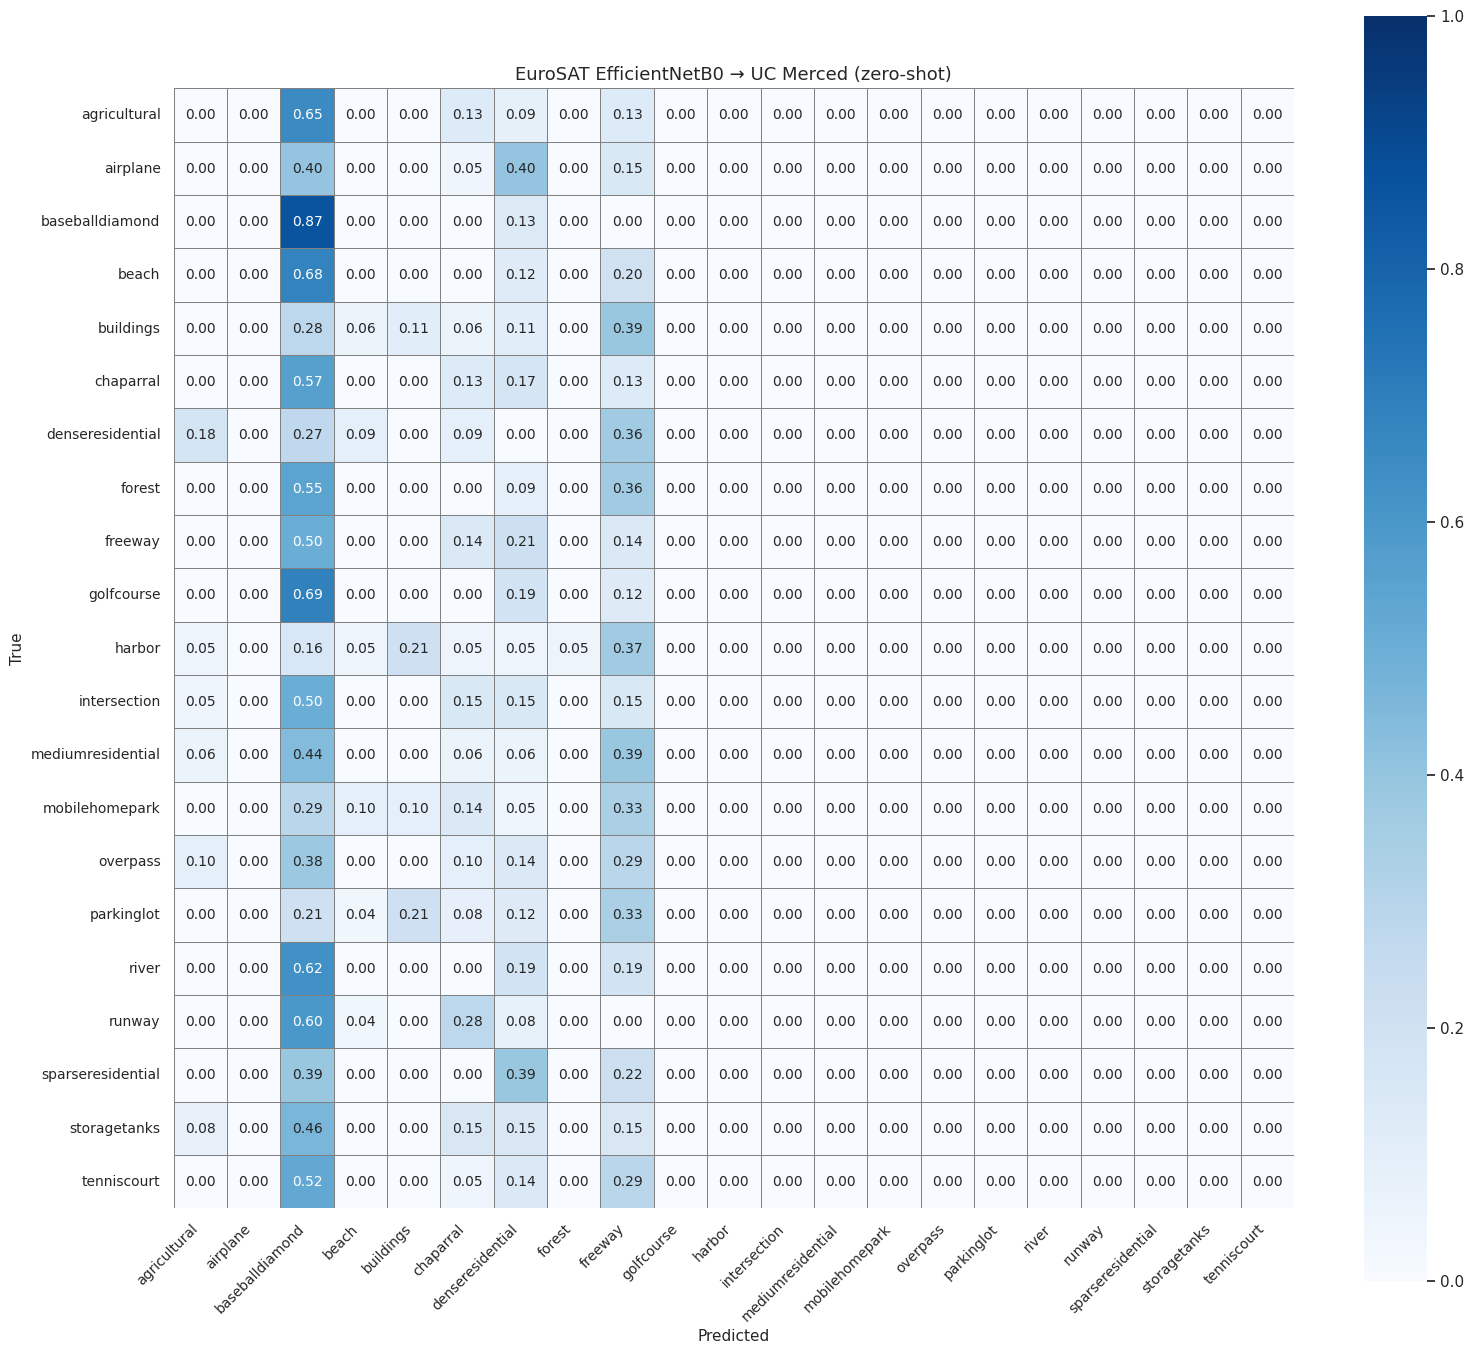

In [ ]:
# EuroSAT EfficientNetB0 → UC Merced
cm_path_eurosat_efficientnet_to_ucm = os.path.join(
    CROSS_NPY_DIR,
    "cross_eurosat_to_ucm_eurosat_efficientnetb0_full_cm.npy"
)

plot_confusion_matrix_from_npy(
    cm_path=cm_path_eurosat_efficientnet_to_ucm,
    class_names=ucm_class_names,
    title="EuroSAT EfficientNetB0 → UC Merced (zero‑shot)",
    normalize=True,
    figsize=(16, 14),
    annot_fontsize=10,
    tick_fontsize=10,
)


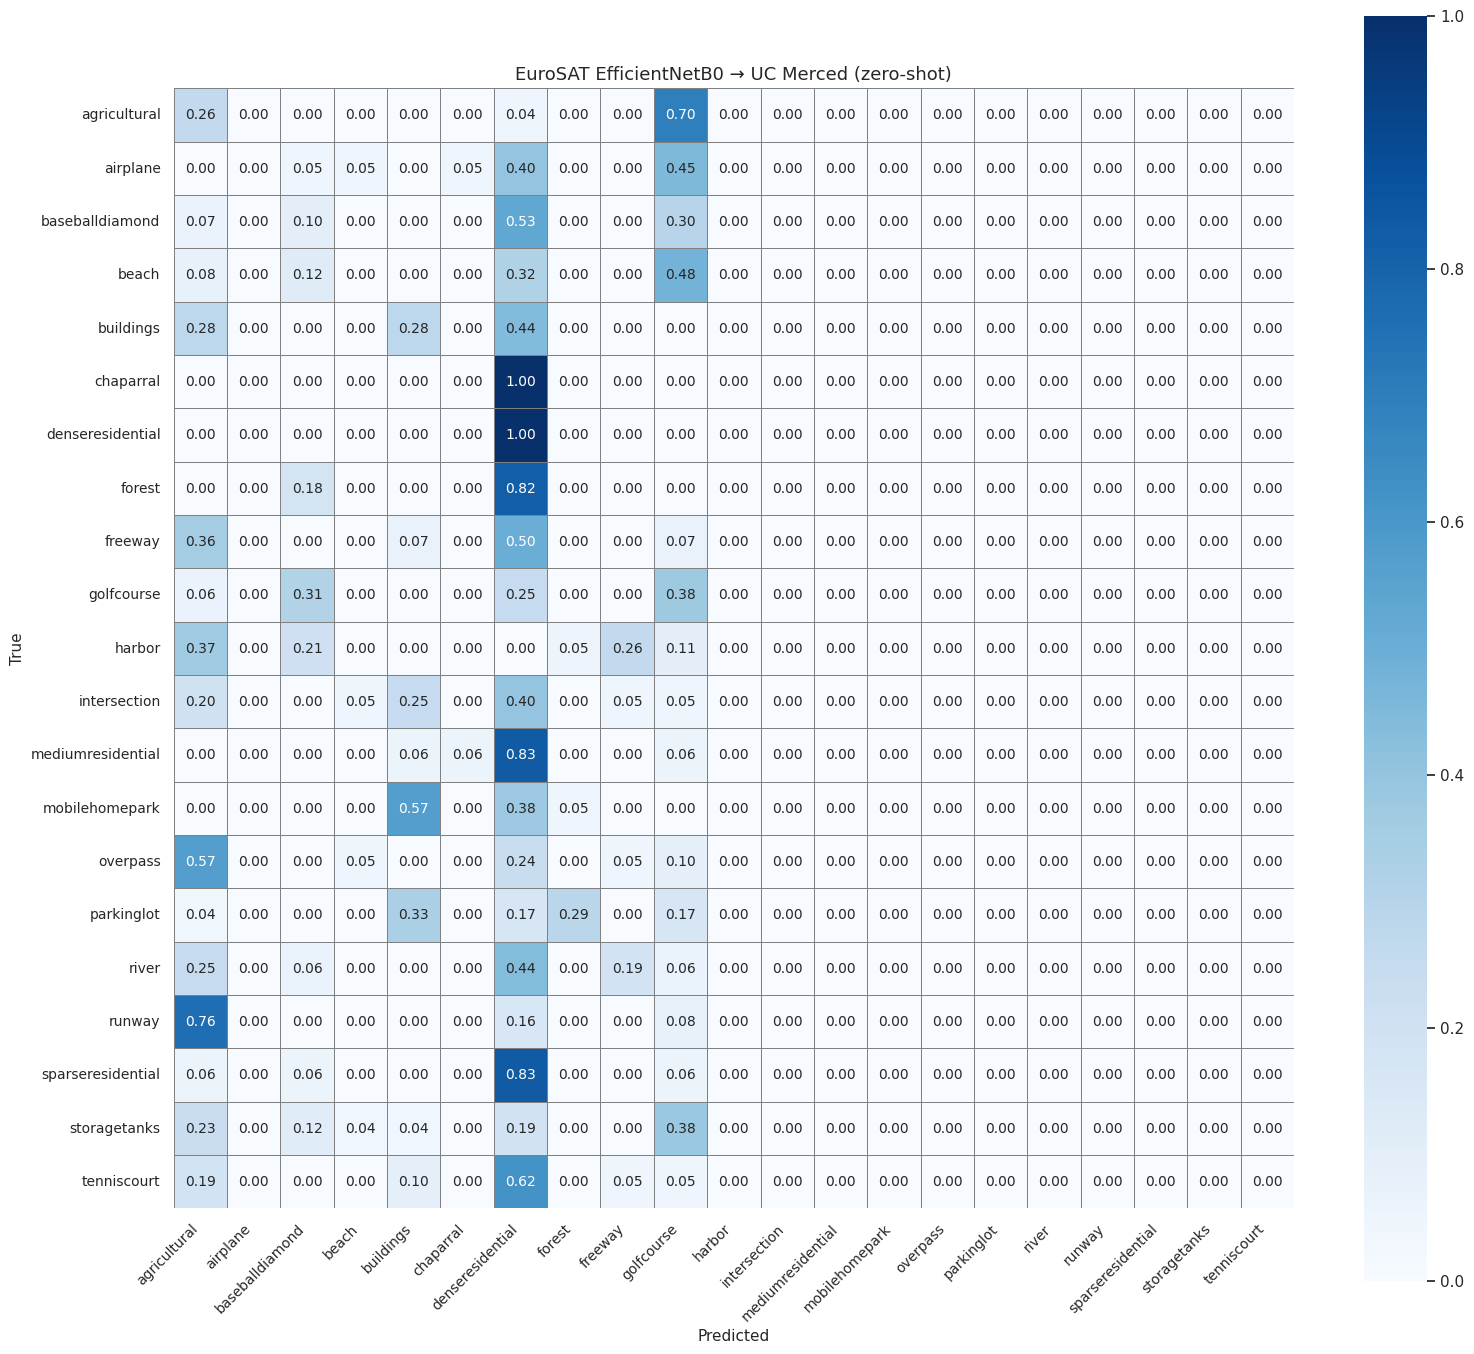

In [ ]:
# EuroSAT EfficientNetB0 → UC Merced
cm_path_eurosat_efficientnet_to_ucm = os.path.join(
    CROSS_NPY_DIR,
    "cross_eurosat_to_ucm_eurosat_densenet121_full_cm.npy"
)

plot_confusion_matrix_from_npy(
    cm_path=cm_path_eurosat_efficientnet_to_ucm,
    class_names=ucm_class_names,
    title="EuroSAT EfficientNetB0 → UC Merced (zero‑shot)",
    normalize=True,
    figsize=(16, 14),
    annot_fontsize=10,
    tick_fontsize=10,
)


**UC Merced → EuroSAT evaluation cell**

In [ ]:
ucm_model_files = [
    "ucm_resnet50_full.keras",
    "ucm_densenet121_full.keras",
    "ucm_mobilenetv2_full.keras",
    "ucm_efficientnetb0_full.keras",
]

zero_shot_results_ucm_to_eurosat = []

for model_file in ucm_model_files:
    model_path = os.path.join(UCM_MODELS_DIR, model_file)
    print("\n======================================")
    print("Evaluating UC Merced model on EuroSAT:", model_path)

    model = tf.keras.models.load_model(model_path, compile=False)

    base_name = model_file.replace(".keras", "")
    prefix = f"cross_ucm_to_eurosat_{base_name}"

    metrics = evaluate_model_on_dataset(
        model=model,
        test_ds=eurosat_test_ds,
        class_names=eurosat_class_names,  # 21 EuroSAT classes
        save_prefix=prefix,
    )

    zero_shot_results_ucm_to_eurosat.append(
        {
            "train_dataset": "UC Merced",
            "test_dataset": "EuroSAT",
            "model": base_name.replace("ucm_", ""),
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
        }
    )

summary_path_u2e = os.path.join(
    CROSS_METRICS_DIR, "zero_shot_ucm_to_eurosat_summary.json"
)
with open(summary_path_u2e, "w") as f:
    json.dump(zero_shot_results_ucm_to_eurosat, f, indent=2)

print("\nSaved UC Merced → EuroSAT zero‑shot summary to:", summary_path_u2e)


Evaluating UC Merced model on EuroSAT: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/models/ucm_resnet50_full.keras
Saved metrics to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/metrics/cross_ucm_to_eurosat_ucm_resnet50_full_metrics.json
Saved y_true to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/npy/cross_ucm_to_eurosat_ucm_resnet50_full_y_true.npy
Saved y_pred to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/npy/cross_ucm_to_eurosat_ucm_resnet50_full_y_pred.npy
Saved confusion matrix to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/npy/cross_ucm_to_eurosat_ucm_resnet50_full_cm.npy
Saved confusion matrix figure to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/figs/cross_ucm_to_eurosat_ucm_resnet50_full_confusion_matrix.png

Evaluating UC Merced model on EuroSAT: /content/drive

**UC Merced → EuroSAT confusion matrix**

UC Merced ResNet50 → EuroSAT (zero‑shot)

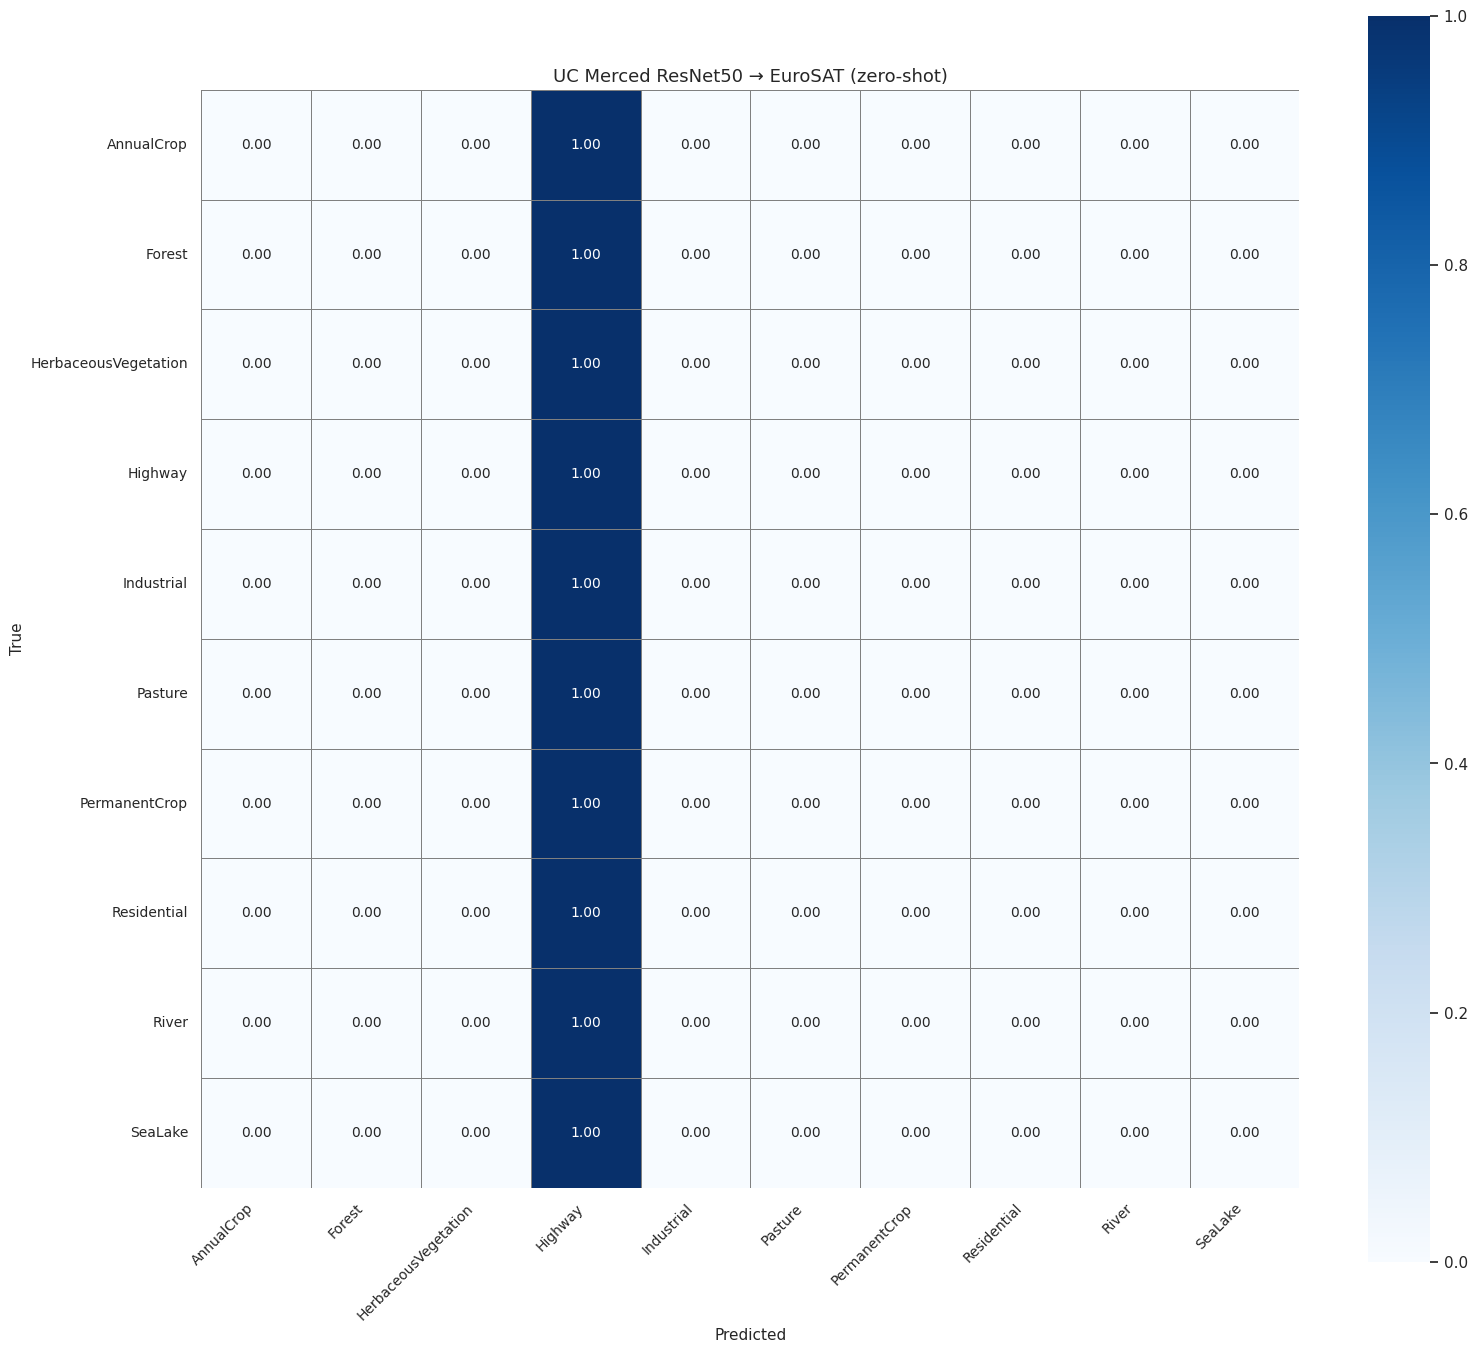

In [ ]:
# UC Merced ResNet50 → EuroSAT (zero‑shot)
cm_path_ucm_resnet_to_eurosat = os.path.join(
    CROSS_NPY_DIR,
    "cross_ucm_to_eurosat_ucm_resnet50_full_cm.npy"
)

plot_confusion_matrix_from_npy(
    cm_path=cm_path_ucm_resnet_to_eurosat,
    class_names=eurosat_class_names,
    title="UC Merced ResNet50 → EuroSAT (zero‑shot)",
    normalize=True,
    figsize=(16, 14),
    annot_fontsize=10,
    tick_fontsize=10,
)

For UC Merced EfficientNetB0 → EuroSAT (zero‑shot)

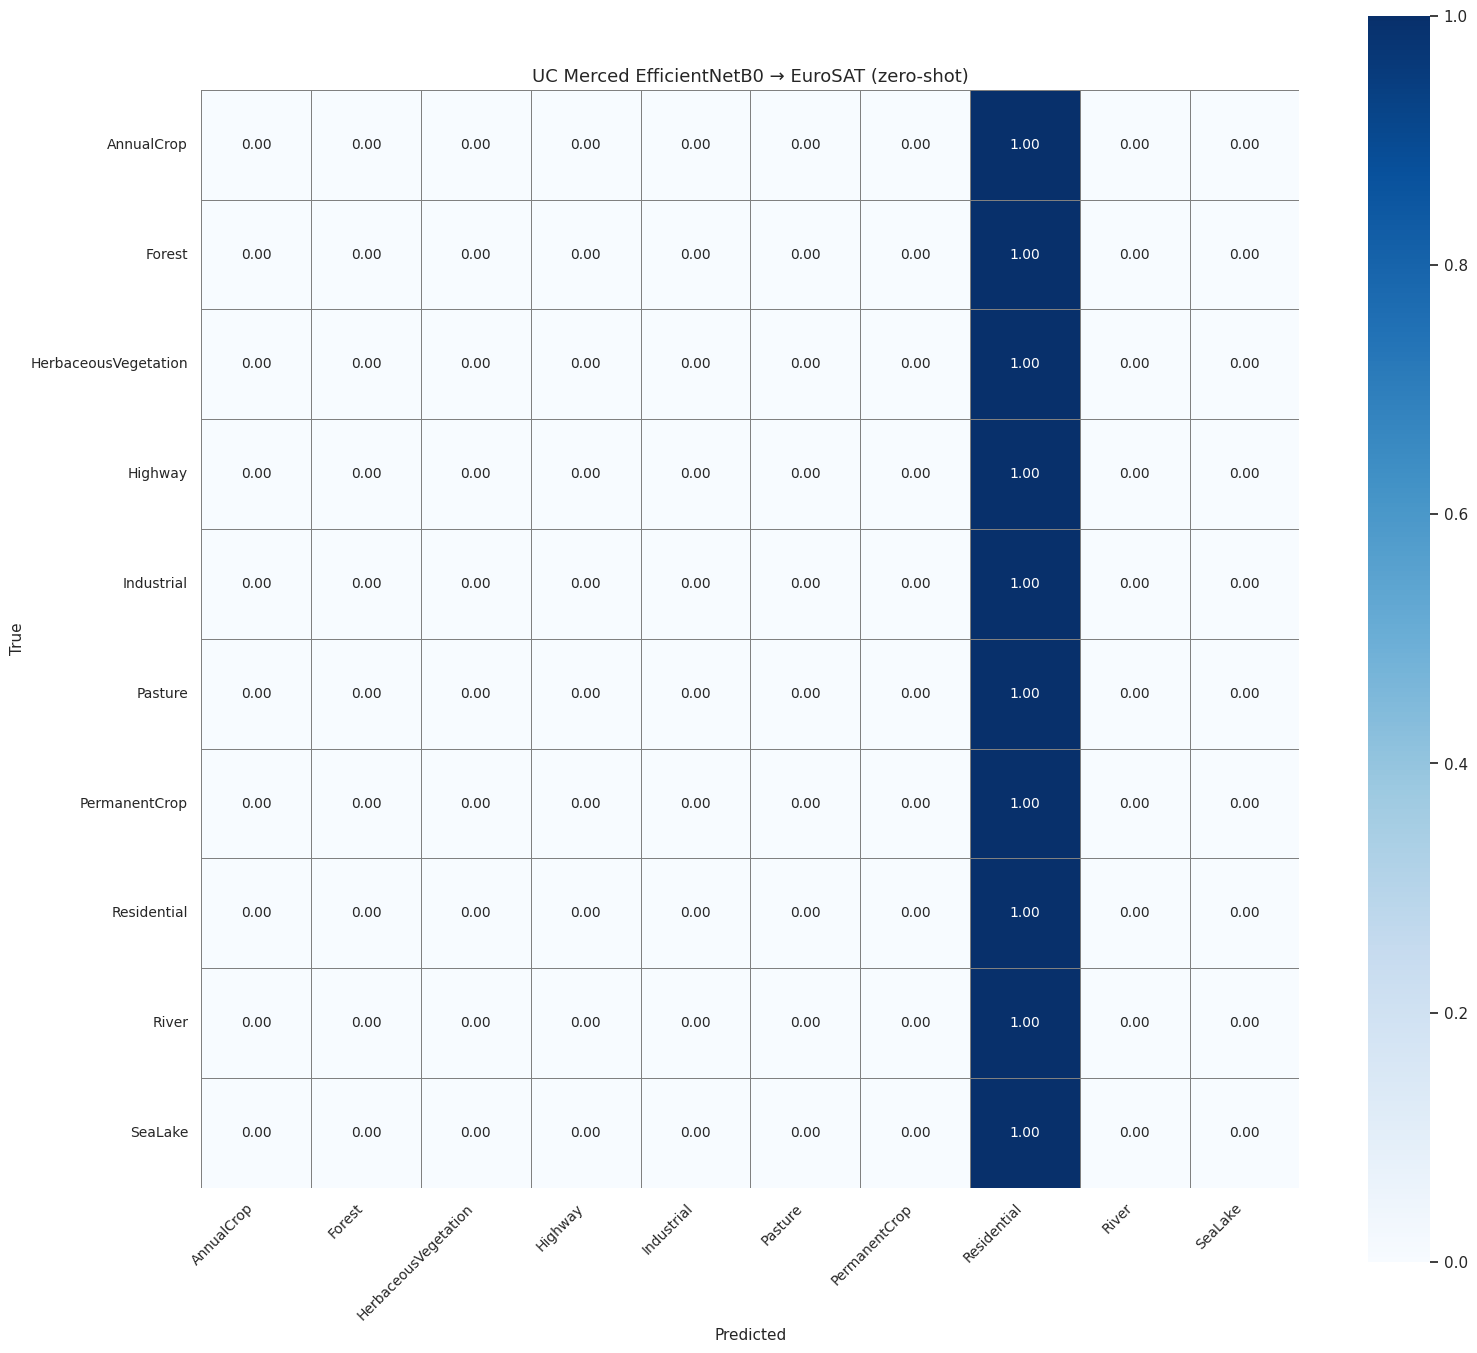

In [ ]:
# UC Merced EfficientNetB0 → EuroSAT
cm_path_ucm_efficientnet_to_eurosat = os.path.join(
    CROSS_NPY_DIR,
    "cross_ucm_to_eurosat_ucm_efficientnetb0_full_cm.npy"
)

plot_confusion_matrix_from_npy(
    cm_path=cm_path_ucm_efficientnet_to_eurosat,
    class_names=eurosat_class_names,
    title="UC Merced EfficientNetB0 → EuroSAT (zero‑shot)",
    normalize=True,
    figsize=(16, 14),
    annot_fontsize=10,
    tick_fontsize=10,
)

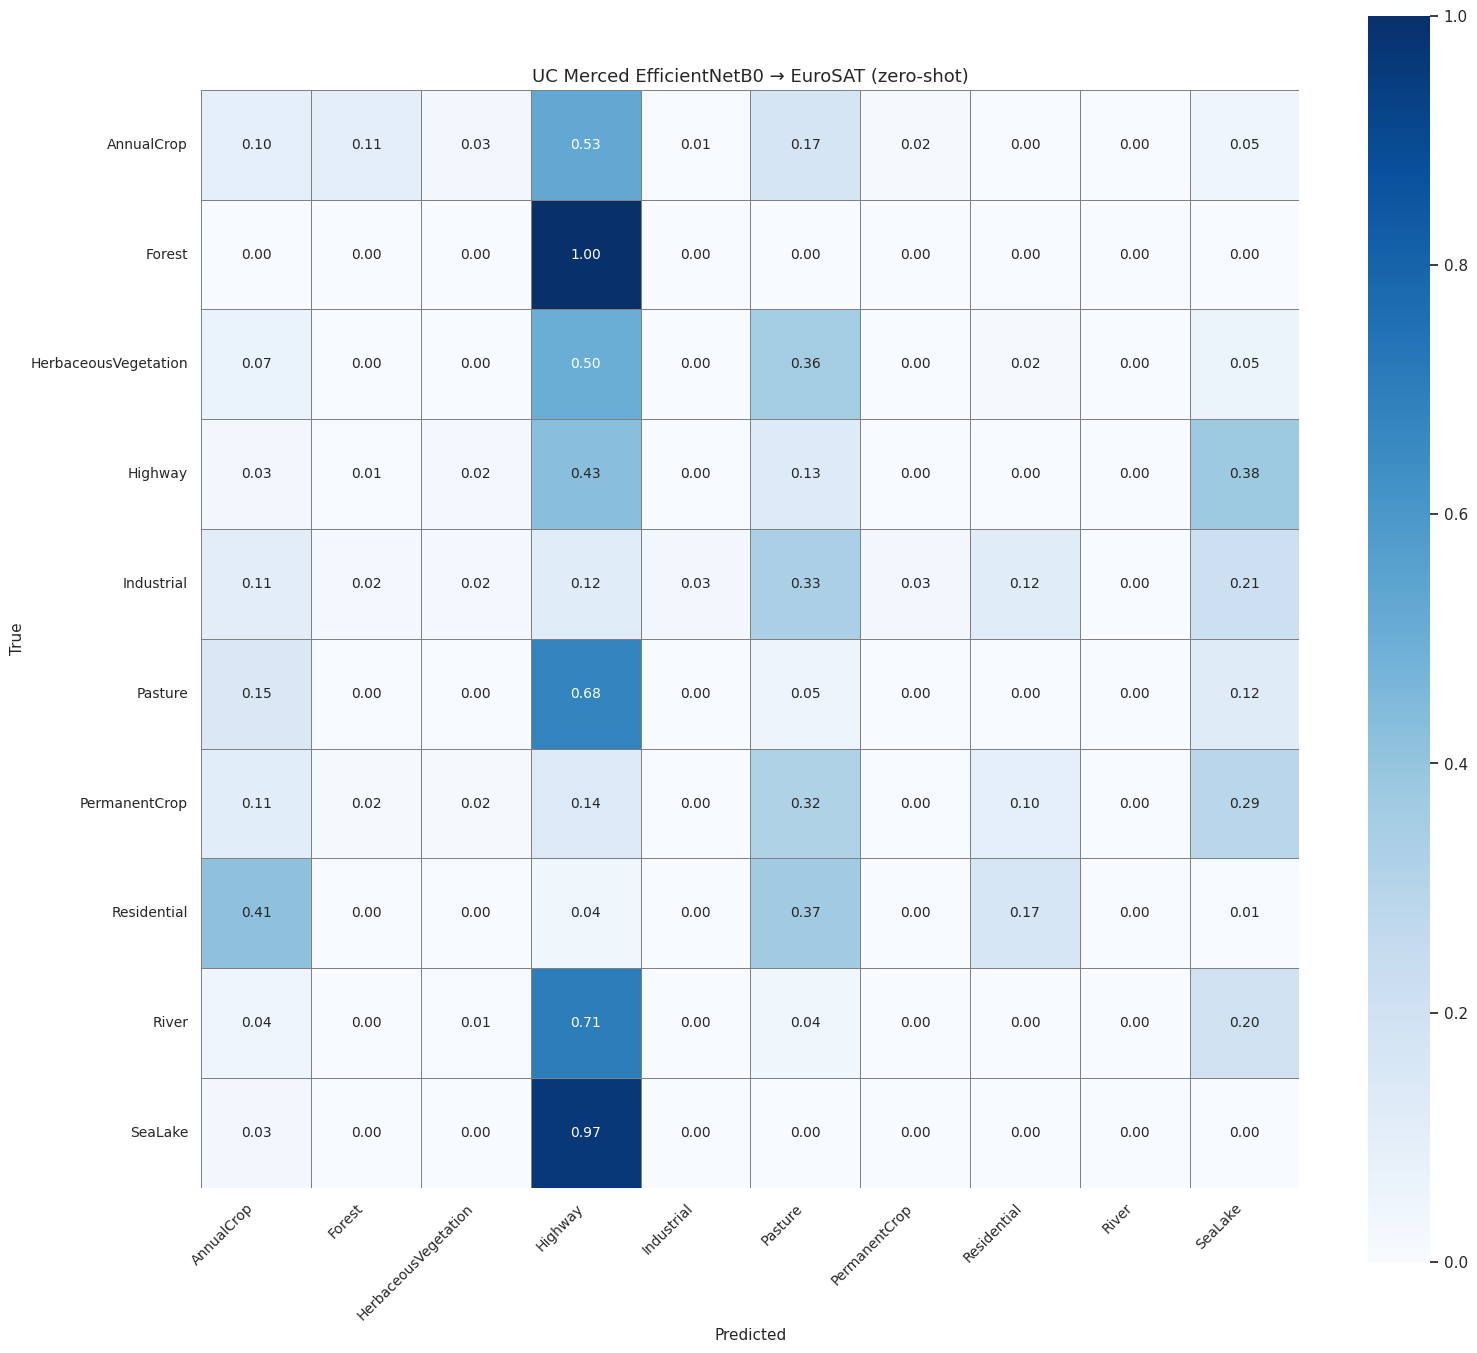

In [ ]:
# UC Merced EfficientNetB0 → EuroSAT
cm_path_ucm_efficientnet_to_eurosat = os.path.join(
    CROSS_NPY_DIR,
    "cross_ucm_to_eurosat_ucm_densenet121_full_cm.npy"
)

plot_confusion_matrix_from_npy(
    cm_path=cm_path_ucm_efficientnet_to_eurosat,
    class_names=eurosat_class_names,
    title="UC Merced EfficientNetB0 → EuroSAT (zero‑shot)",
    normalize=True,
    figsize=(16, 14),
    annot_fontsize=10,
    tick_fontsize=10,
)

# Evaluation


In [ ]:
import os, glob, json
import pandas as pd

# 1) Load zero‑shot summaries
summary_path_e2u = os.path.join(CROSS_METRICS_DIR, "zero_shot_eurosat_to_ucm_summary.json")
summary_path_u2e = os.path.join(CROSS_METRICS_DIR, "zero_shot_ucm_to_eurosat_summary.json")

with open(summary_path_e2u, "r") as f:
    zero_shot_results_eurosat_to_ucm = json.load(f)

with open(summary_path_u2e, "r") as f:
    zero_shot_results_ucm_to_eurosat = json.load(f)

df_e2u = pd.DataFrame(zero_shot_results_eurosat_to_ucm)
df_u2e = pd.DataFrame(zero_shot_results_ucm_to_eurosat)


In [ ]:
import os, glob, json
import numpy as np
import pandas as pd

def build_in_domain_summary_with_f1(metrics_dir, prefix):
    rows = []
    pattern = os.path.join(metrics_dir, f"{prefix}*_test_metrics.json")
    for path in glob.glob(pattern):
        fname = os.path.basename(path)
        model_name = fname.replace(f"{prefix}", "").replace("_test_metrics.json", "")
        with open(path, "r") as f:
            m = json.load(f)

        acc = float(m.get("accuracy", m.get("test_accuracy", float("nan"))))

        # Try direct macro_f1 first, otherwise derive from classification_report
        if "macro_f1" in m:
            macro_f1 = float(m["macro_f1"])
        else:
            cr = m.get("classification_report", {})
            # scikit-learn style: 'macro avg' entry with 'f1-score'
            if "macro avg" in cr and "f1-score" in cr["macro avg"]:
                macro_f1 = float(cr["macro avg"]["f1-score"])
            else:
                macro_f1 = float("nan")

        rows.append(
            {
                "model": model_name,
                "test_accuracy": acc,
                "macro_f1": macro_f1,
            }
        )
    return pd.DataFrame(rows)

eurosat_summary = build_in_domain_summary_with_f1(EUROSAT_METRICS_DIR, "eurosat_")
ucm_summary     = build_in_domain_summary_with_f1(UCM_METRICS_DIR, "ucm_")

print("EuroSAT in‑domain summary:")
display(eurosat_summary)

print("UC Merced in‑domain summary:")
display(ucm_summary)


EuroSAT in‑domain summary:


,model,test_accuracy,macro_f1
0,resnet50,0.985000,0.984418
1,densenet121,0.981667,0.981163
2,mobilenetv2,0.855000,0.853497
3,efficientnetb0,0.975556,0.974711


UC Merced in‑domain summary:


,model,test_accuracy,macro_f1
0,resnet50,0.947619,0.946993
1,mobilenetv2,0.916667,0.918823
2,efficientnetb0,0.940476,0.936410
3,densenet121,0.945238,0.944572


In [ ]:
print("Zero‑shot EuroSAT → UCM models:", df_e2u["model"].unique())
print("EuroSAT in‑domain models:", eurosat_summary["model"].unique())

print("\nZero‑shot UCM → EuroSAT models:", df_u2e["model"].unique())
print("UC Merced in‑domain models:", ucm_summary["model"].unique())

Zero‑shot EuroSAT → UCM models: ['resnet50_full' 'densenet121_full' 'mobilenetv2_full'
 'efficientnetb0_full']
EuroSAT in‑domain models: ['resnet50' 'densenet121' 'mobilenetv2' 'efficientnetb0']

Zero‑shot UCM → EuroSAT models: ['resnet50_full' 'densenet121_full' 'mobilenetv2_full'
 'efficientnetb0_full']
UC Merced in‑domain models: ['resnet50' 'mobilenetv2' 'efficientnetb0' 'densenet121']


In [ ]:
def normalize_model_name(name: str) -> str:
    # strip common suffixes like '_full'
    return name.replace("_full", "").strip()

# Build lookup dicts with normalized keys
euro_lookup = {
    normalize_model_name(m): row
    for m, row in eurosat_summary.set_index("model").iterrows()
}
ucm_lookup = {
    normalize_model_name(m): row
    for m, row in ucm_summary.set_index("model").iterrows()
}

rows = []

# EuroSAT → UCM
for _, r in df_e2u.iterrows():
    raw_name = r["model"]                 # e.g., 'resnet50' or 'resnet50_full'
    key = normalize_model_name(raw_name)  # normalized for lookup
    if key not in euro_lookup:
        raise ValueError(f"Model '{raw_name}' (key '{key}') not found in eurosat_summary")
    in_row = euro_lookup[key]

    rows.append(
        {
            "train_dataset": "EuroSAT",
            "test_dataset": "UC Merced",
            "model": key,
            "in_domain_accuracy": float(in_row["test_accuracy"]),
            "in_domain_macro_f1": float(in_row["macro_f1"]),
            "zero_shot_accuracy": float(r["accuracy"]),
            "zero_shot_macro_f1": float(r["macro_f1"]),
        }
    )

# UC Merced → EuroSAT
for _, r in df_u2e.iterrows():
    raw_name = r["model"]
    key = normalize_model_name(raw_name)
    if key not in ucm_lookup:
        raise ValueError(f"Model '{raw_name}' (key '{key}') not found in ucm_summary")
    in_row = ucm_lookup[key]

    rows.append(
        {
            "train_dataset": "UC Merced",
            "test_dataset": "EuroSAT",
            "model": key,
            "in_domain_accuracy": float(in_row["test_accuracy"]),
            "in_domain_macro_f1": float(in_row["macro_f1"]),
            "zero_shot_accuracy": float(r["accuracy"]),
            "zero_shot_macro_f1": float(r["macro_f1"]),
        }
    )

day2_zero_shot_table = pd.DataFrame(rows)
print("Day‑2 zero‑shot comparison table:")
display(day2_zero_shot_table)

Day‑2 zero‑shot comparison table:


,train_dataset,test_dataset,model,in_domain_accuracy,in_domain_macro_f1,zero_shot_accuracy,zero_shot_macro_f1
0,EuroSAT,UC Merced,resnet50,0.985000,0.984418,0.038095,0.003495
1,EuroSAT,UC Merced,densenet121,0.981667,0.981163,0.073810,0.031571
2,EuroSAT,UC Merced,mobilenetv2,0.855000,0.853497,0.059524,0.041761
3,EuroSAT,UC Merced,efficientnetb0,0.975556,0.974711,0.078571,0.023430
4,UC Merced,EuroSAT,resnet50,0.947619,0.946993,0.093333,0.017073
5,UC Merced,EuroSAT,densenet121,0.945238,0.944572,0.069815,0.025809
6,UC Merced,EuroSAT,mobilenetv2,0.916667,0.918823,0.094630,0.020512
7,UC Merced,EuroSAT,efficientnetb0,0.940476,0.936410,0.112593,0.020240


In [ ]:
day2_table_path = os.path.join(
    CROSS_METRICS_DIR, "day2_zero_shot_comparison_table.csv"
)
day2_zero_shot_table.to_csv(day2_table_path, index=False)
print("Saved Day‑2 zero‑shot comparison table to:", day2_table_path)

Saved Day‑2 zero‑shot comparison table to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/cross_dataset_zero_shot/metrics/day2_zero_shot_comparison_table.csv
